# Fine-tuning U-Net architecture
Modèles basés sur l'architeture U-Net :
- U-Net avec encodeur ResNet34
- ResAttentionUNetPlusPlus
- Attention Gated Multi ResU-Net
- CSA-Net
- xLSTM-UNet

In [1]:
import numpy as np
import torch
import torch.optim as optim
import pickle 
import time
import sys
import pandas as pd

from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

# Importation des classes de dataset personnalisées
from utils.dataset_unet import RoboflowUNetDataset

# Importation des fonctions utilitaires
from utils.models_config import collate_fn, split_dataset, BCE_DiceLoss, dataset_to_dict, BCE_DiceLoss_ignore
from utils.post_traitement import keep_largest_components

# Importation des modèles U-Net personnalisés
from models.ResAttentionUNetPlusPlus import ResAttentionUNetPlusPlus
from models.AttentionMultiResUNet import AttentionMultiResUNet

/home/ldepiero/Debut/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import random

# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Importation et traitement des données

In [3]:
# -------- 1. Importation des données --------
all_images_dir = "../data/COCO/images"  # Images
annotations_json = "../data/COCO/annotations.json" # Fichier JSON COCO

#annotations_json = "../data/COCO/annotations_2_classes.json" # Cas avec 2 classes

# Importation du Data Frame avec les metadata
df = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# Formatage et regroupement des images et des annotations dans un dictionnaire pour faciliter l'accès aux données
# ignore_category_id : id COCO de la catégorie "Gonade_ignore" si elle existe dans l'export (None sinon).
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(df, annotations_json, all_images_dir)

# Canal du masque sur lequel appliquer la zone "ignore" (uniquement la classe Gonade)
gonade_cat_id = next(cid for cid, name in categories.items() if name == "Gonade")
gonade_channel_idx = class_ids.index(gonade_cat_id)

Classes détectées (3) : {1: 'Cavite', 2: 'Gonade', 3: 'Intestin'}
Catégorie ignore détectée : 'ignore' (id=4)


### Division du jeu de données

In [4]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test, cv_dataset, test_dataset = split_dataset(all_samples, all_images_dir, df, IMAGE_SIZE, num_classes, 
                                                                                                                              class_ids, dim="2")
print(f"Shape des images: {test_dataset[0]['image'].shape}")

Nombre total d'images valides : 86
Échantillons train/val        : 71
Échantillons de test          : 15
Shape des images: torch.Size([3, 512, 512])


### Hyperparamètres du modèle et initialisation

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

# ---- Hyperparamètres ----
epochs = 200
nb_channels = 3
learning_rate = 1e-4

# ---- Fct de perte ----
# BCE_DiceLoss_ignore : identique à BCE_DiceLoss mais exclut les pixels marqués -100
# (zones "ignore") du calcul de la BCE et du Dice.
loss_fn = BCE_DiceLoss_ignore(bce_weight=0.5, dice_weight=0.5, ignore_index=-100) # Fct de perte combinée BCE + Dice Loss

# ---- Early stopping config ----
early_stopping_patience = 10  # nombre d'epochs sans amélioration avant arrêt
early_stopping_min_delta = 1e-3  # amélioration minimale considérée comme significative

# ---- Cross validation k-folds ----
k_folds = 5
kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)
X = np.array(cv_samples, dtype=object) # Les images

# Initialisation
fold_results = {}
fold_histories = {}
best_epochs = []

Utilisation de l'appareil: cuda


### Images selectionnées par batch

In [12]:
# ------------------ ENTRAINEMENT + VALIDATION ------------------
for fold, (train_idx, val_idx) in enumerate(kf.split(X, cv_categories, groups_train)):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    val_names = [x["image_info"]["file_name"] for x in cv_samples[val_idx]]
    print(val_names)


--- DEBUT DU FOLD 1/5 ---
['0004652_11.23.44_356868_2019.jpg', '0004653_11.23.56_356868_2019.jpg', '0004654_11.24.05_356868_2019.jpg', '0004655_11.24.32_356868_2019.jpg', '0004657_11.29.44_356877_2019.jpg', '0004658_11.29.54_356877_2019.jpg', '0004734_11.20.45_357305_2019.jpg', '0004735_11.20.53_357305_2019.jpg', '0004736_11.21.16_357305_2019.jpg', '0007101_09.42.42_427181_2024.jpg', '0007102_09.42.49_427181_2024.jpg', '0007103_09.43.00_427181_2024.jpg', '0007104_09.43.08_427181_2024.jpg', '0007105_09.43.17_427181_2024.jpg']
--- DEBUT DU FOLD 2/5 ---
['0004586_12.06.43_356418_2019.jpg', '0004587_12.06.54_356418_2019.jpg', '0004588_12.07.07_356418_2019.jpg', '0004589_12.07.19_356418_2019.jpg', '0006954_11.06.31_426770_2024.jpg', '0006955_11.06.41_426770_2024.jpg', '0006956_11.06.49_426770_2024.jpg', '0007107_09.45.42_427184_2024.jpg', '0007108_09.45.49_427184_2024.jpg', '0007109_09.45.54_427184_2024.jpg', '0007110_09.46.00_427184_2024.jpg', '0007111_09.46.06_427184_2024.jpg', '0007131_1

### Entrainement et validation du modèle

In [14]:
# ------------------ ENTRAINEMENT + VALIDATION ------------------
for fold, (train_idx, val_idx) in enumerate(kf.split(X, cv_categories, groups_train)):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    fold_start_time = time.time() # Initialisation temps d'execution du fold

    # -------- 1. Création des jeux de données pour ce fold --------
    train_samples = [cv_samples[i] for i in train_idx]
    val_samples = [cv_samples[i] for i in val_idx]

    # Échelle en cm par pixel réelle, propre à chaque image de validation de ce fold
    # (colonne "echelle" de df), alignée sur l'ordre de val_samples / val_loader (shuffle=False).
    echelle_val_fold = np.array([
        df.loc[df["image_id"] == s["image_info"]["file_name"].split("_")[0], "echelle"].values[0]
        for s in val_samples
    ]) / IMAGE_SIZE[1]

    # Générateur dédié au shuffle du train_loader pour que l'ordre des batchs soit identique quel que soit le modèle comparé.
    loader_g = torch.Generator()
    loader_g.manual_seed(SEED + fold)

    train_dataset = RoboflowUNetDataset(samples=train_samples, image_dir=all_images_dir, df = df, image_size=IMAGE_SIZE, 
                                        num_classes=num_classes, class_ids=class_ids, is_train = True,
                                        ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_channel_idx)
    val_dataset = RoboflowUNetDataset(samples=val_samples, image_dir=all_images_dir, df = df, image_size=IMAGE_SIZE, 
                                      num_classes=num_classes, class_ids=class_ids, is_train=False,
                                      ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_channel_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn, generator=loader_g)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

    # Sauvegarde des Op et des catégories pour l'éch de validation
    val_categories_fold = [sample['category'] for sample in val_samples]
    val_ops_fold = [int(sample['position']) for sample in val_samples]
    val_ops_ratio_fold = [float(sample['position_ratio']) for sample in val_samples]

    # -------- 2. Réinitialisation complète du Modèle et Optimiseur --------
    # Rend l'initialisation des poids (et le dropout éventuel) reproductible d'un run à l'autre pour un même modèle
    torch.manual_seed(SEED + fold)
    torch.cuda.manual_seed_all(SEED + fold)

    # ----- CHOIX DU MODELE -----
    # U-Net classique
    model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=nb_channels, classes=num_classes, activation=None)

    # Attention UNet ++
    #model = ResAttentionUNetPlusPlus(num_classes=num_classes,in_channels=nb_channels,encoder_weights="imagenet")

    # Attention MultiResUNet
    #model = AttentionMultiResUNet(in_ch=nb_channels, num_classes=num_classes)

    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4) # Optimiseur AdamW and une regularisation L2 (weight decay) pour éviter l'overfitting
    # Scheduler pour réduire le learning rate si la validation loss ne s'améliore pas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

    # -------- 2. Initialisation par fold --------
    # Dictionnaires pour sauvegarder les résultats
    history = {'train_loss': [], 
               'val_loss': [], 
               'val_iou': [],
               'val_iou_all' : [],
               'val_surf_diff_cm2': [],
               }
    
    best_epochs = {'iou_gonade': [],
                   'iou_cavite': [],
                    'iou_all' : [],
                    'category': [],
                    'ops': [],
                    'ops_ratio': [],
                    'diff_surf': [],
                    'name': []
                    }
    
    best_val_loss = float('inf')
    idx_best_epoch = -1
    early_stopping_counter = 0
    idx_best_epochs = []

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        # Epoch courante : utilisée par le dataset pour dériver un seed d'augmentation déterministe et identique entre modèles comparés.
        train_dataset.epoch = epoch
        val_dataset.epoch = epoch
        
        # -------------- 3. Training --------------
        model.train()
        running_loss = 0.0
        running_count = 0
        for batch in train_loader:
            images = batch['image'].to(device, non_blocking=True)
            masks = batch['mask'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images) # Outputs à trois canaux (1 par classe)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            # Perte cumulée
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_count += batch_size

        # Calcul de la perte moyenne de l'epoch
        avg_train_loss = running_loss / running_count if running_count > 0 else 0.0

        # -------------- 4. Validation ----------------
        model.eval()
        val_loss = 0.0
        val_count = 0.0

        epoch_intersection_gonade = torch.tensor(0.0, device=device)
        epoch_union_gonade = torch.tensor(0.0, device=device)
        epoch_intersection_all = torch.tensor(0.0, device=device)
        epoch_union_all = torch.tensor(0.0, device=device)
        total_diff_surf_cm2 = torch.tensor(0.0, device=device)

        epoch_all_iou_tensors = []
        epoch_iou_gonade_tensors = []
        epoch_iou_cavite_tensors = []
        epoch_diff_surf_tensors = []
        epoch_categories = []
        epoch_ops = []
        epoch_ops_ratio = []

        val_sample_offset = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device, non_blocking=True)
                masks = batch['mask'].to(device, non_blocking=True)

                outputs = model(images)
                loss = loss_fn(outputs, masks)

                # Cumul de la perte et du nombre d'échantillons
                batch_size = images.size(0)
                val_loss += loss.item() * batch_size
                val_count += batch_size

                # Échelle des images de ce batch (mêmes indices que val_samples, val_loader n'est pas mélangé)
                echelle_batch = torch.tensor(
                    echelle_val_fold[val_sample_offset:val_sample_offset + batch_size],
                    device=device, dtype=torch.float32
                ).view(-1, 1)
                val_sample_offset += batch_size

                # --- Prédictions ---
                # valid_mask exclut les pixels marqués -100 (zones "ignore") : ni le vrai
                # masque ni la prédiction n'y contribuent, donc ils sont exclus de l'IoU/surface
                # exactement comme s'ils n'existaient pas (au lieu d'être comptés comme "pas de gonade").
                valid_mask = masks != -100
                probs = torch.sigmoid(outputs)
                true = (masks > 0.5) & valid_mask
                preds = (probs > 0.5) & valid_mask

                # --- Post-processing : garder uniquement la plus grande composante ---
                preds = keep_largest_components(preds) & valid_mask

                # --- Calcul de l'IoU ---
                intersection = (preds & true).float().sum((2, 3))
                union = (preds | true).float().sum((2, 3))   
                
                iou_per_img = intersection / (union + 1e-6)  
                iou_per_img[union==0] = 1.0
                iou_gonade = iou_per_img[:,1]
                iou_cavite = iou_per_img[:,0]

                epoch_iou_gonade_tensors.append(iou_gonade)
                epoch_iou_cavite_tensors.append(iou_cavite)
                epoch_all_iou_tensors.append(iou_per_img)
                
                # Cumul pour l'IoU Global de l'epoch
                epoch_intersection_gonade += intersection[:, 1].sum()
                epoch_union_gonade += union[:, 1].sum()
                epoch_intersection_all += intersection.sum()
                epoch_union_all += union.sum()
                
                #--- Calcul des surfaces en cm2 ---
                pred_surf_pixels = preds.float().sum((2, 3))
                true_surf_pixels = true.float().sum((2, 3))
                diff_surf_pixels = (true_surf_pixels - pred_surf_pixels).abs()
                diff_surf_cm2 = diff_surf_pixels * (echelle_batch ** 2)

                diff_surf_cm2_gonade = diff_surf_cm2[:,1] # Récupère les surfaces uniquement des gonades

                epoch_diff_surf_tensors.append(diff_surf_cm2_gonade)
                total_diff_surf_cm2 += diff_surf_cm2_gonade.sum()                

        # Transfer sur le CPU en fin d'epoch
        epoch_iou_gonade = torch.cat(epoch_iou_gonade_tensors).cpu().tolist()
        epoch_all_iou = torch.cat(epoch_all_iou_tensors).cpu().tolist()
        epoch_iou_cavite = torch.cat(epoch_iou_cavite_tensors).cpu().tolist()
        epoch_diff_surf = torch.cat(epoch_diff_surf_tensors).cpu().tolist()

        # Fin de la validation de l'epoch
        avg_val_loss = val_loss / val_count
        mean_val_iou = (epoch_intersection_gonade / (epoch_union_gonade + 1e-6)).item()
        mean_val_iou_all = (epoch_intersection_all / (epoch_union_all + 1e-6)).item()
        mean_diff_cm2 = (total_diff_surf_cm2).item() / val_count

        scheduler.step(avg_val_loss) # Scheduler

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_iou'].append(mean_val_iou)
        history['val_iou_all'].append(mean_val_iou_all)
        history['val_surf_diff_cm2'].append(mean_diff_cm2)
        
        # Early stopping + sauvegarde
        if avg_val_loss + early_stopping_min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            idx_best_epoch = epoch
            torch.save(model.state_dict(), f"unet_finetuned_fold_{fold+1}.pth")
            early_stopping_counter = 0  # reset counter

            best_epochs['iou_all'] = epoch_all_iou
            best_epochs['iou_gonade'] = epoch_iou_gonade
            best_epochs['iou_cavite'] = epoch_iou_cavite
            best_epochs['category'] = val_categories_fold
            best_epochs['ops'] = val_ops_fold
            best_epochs['ops_ratio'] = val_ops_ratio_fold
            best_epochs['diff_surf'] = epoch_diff_surf
            best_epochs['name '] = [sample['image_info']['file_name'] for sample in val_samples]

        else:
            early_stopping_counter += 1

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch}/{epochs} — train_loss: {avg_train_loss:.4f}, val_loss: {avg_val_loss:.4f}, val_iou: {mean_val_iou_all:.4f}, time: {epoch_time:.1f}s, lr : {optimizer.param_groups[0]['lr']:.2e}, early_stopping: {early_stopping_counter}/{early_stopping_patience}")

        if early_stopping_counter >= early_stopping_patience:
            print(f"EarlyStopping: arrêt après {early_stopping_counter} epochs sans amélioration (patience={early_stopping_patience}).")
            break
        
    # Résultats finaux
    print(f"Meilleur epoch (selon val_loss): {idx_best_epoch} avec val_loss={best_val_loss:.4f}")
    print(f"Modèle sauvegardé sous unet_finetuned_{fold+1}.pth (dernier best)")
    
    # Sauvegarde du temps d'execution
    fold_total_time = time.time() - fold_start_time
    history['fold_time_seconds'] = fold_total_time
    
    fold_results[f'fold_{fold+1}'] = best_epochs
    fold_histories[f'fold_{fold+1}'] = history
    idx_best_epochs.append(idx_best_epoch)

--- DEBUT DU FOLD 1/5 ---
Epoch 1/200 — train_loss: 0.7493, val_loss: 0.7775, val_iou: 0.0272, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 2/200 — train_loss: 0.6927, val_loss: 0.7435, val_iou: 0.1982, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 3/200 — train_loss: 0.6650, val_loss: 0.6936, val_iou: 0.3713, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 4/200 — train_loss: 0.6384, val_loss: 0.6617, val_iou: 0.4592, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 5/200 — train_loss: 0.6201, val_loss: 0.6303, val_iou: 0.5263, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 6/200 — train_loss: 0.6058, val_loss: 0.6086, val_iou: 0.5639, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 7/200 — train_loss: 0.5881, val_loss: 0.5923, val_iou: 0.5656, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 8/200 — train_loss: 0.5784, val_loss: 0.5784, val_iou: 0.6051, time: 3.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 9/200 — train_loss: 0.5678, val_

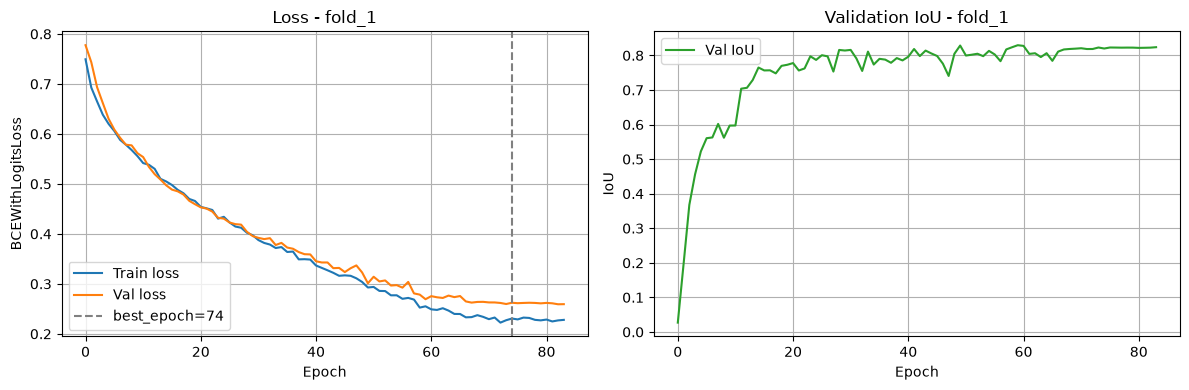

=== FOLD_1 ===
Train loss per epoch: [0.7493144211016203, 0.6927294051438048, 0.6650452885711402, 0.6384404824491132, 0.6200977731169316, 0.60578803848802, 0.5881372209180865, 0.5783988456977042, 0.5677513009623477, 0.5557478038888228, 0.5416431447915864, 0.5382241209348043, 0.5300878024937814, 0.5101149803713748, 0.5048493324664601, 0.49775153816792, 0.48807655719288606, 0.48124647558781136, 0.46986903956061915, 0.4657783137078871, 0.45408595967711063, 0.4511001606782277, 0.44782086213429767, 0.43052098991578086, 0.4341283618358144, 0.422818638776478, 0.41471384805545475, 0.41230449132752, 0.4023254806535286, 0.39731466508748237, 0.38761606917046665, 0.38187677295584427, 0.3786750017550954, 0.3717283292820579, 0.37359511015707986, 0.3637787286649671, 0.3646538686334041, 0.34901460534647893, 0.34935775190068963, 0.34860769437070477, 0.33670781422079654, 0.33195176982043084, 0.3271292897692898, 0.32208618887683804, 0.3161386303734361, 0.3170173518490373, 0.31613379089455856, 0.311125524

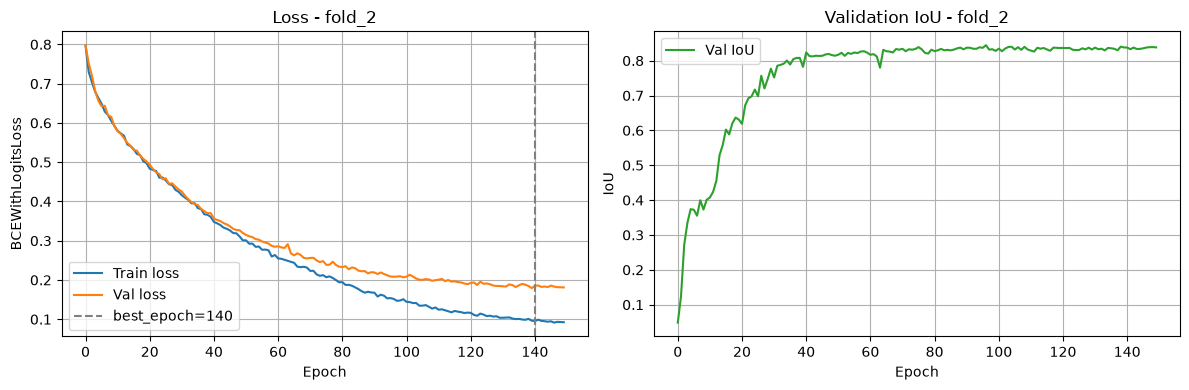

=== FOLD_2 ===
Train loss per epoch: [0.7964692796979632, 0.7294329404830933, 0.7035538724490574, 0.6796311225209918, 0.6635105780192784, 0.6489045875413078, 0.628964935030256, 0.6199788110596793, 0.6053883518491473, 0.5928337914603097, 0.579768283026559, 0.5733404500143868, 0.5672758391925267, 0.5451682720865522, 0.5409417493002755, 0.5330820764814105, 0.5211038674627032, 0.517956576177052, 0.5024226222719465, 0.4974628984928131, 0.4833632707595825, 0.48055243492126465, 0.4775109461375645, 0.46054272992270334, 0.4609975814819336, 0.453652377639498, 0.4437846669128963, 0.4420171635491507, 0.42960805552346365, 0.4247274100780487, 0.41588946751185824, 0.4096044344561441, 0.4040371818201883, 0.3953000477382115, 0.3953626496451242, 0.38287957651274546, 0.38046486037118094, 0.3673658924443381, 0.36598214507102966, 0.3608479244368417, 0.3479174929005759, 0.34426577602113995, 0.3400461758886065, 0.33331032735960825, 0.33029073902538847, 0.3262139218194144, 0.3195791116782597, 0.31881097810609

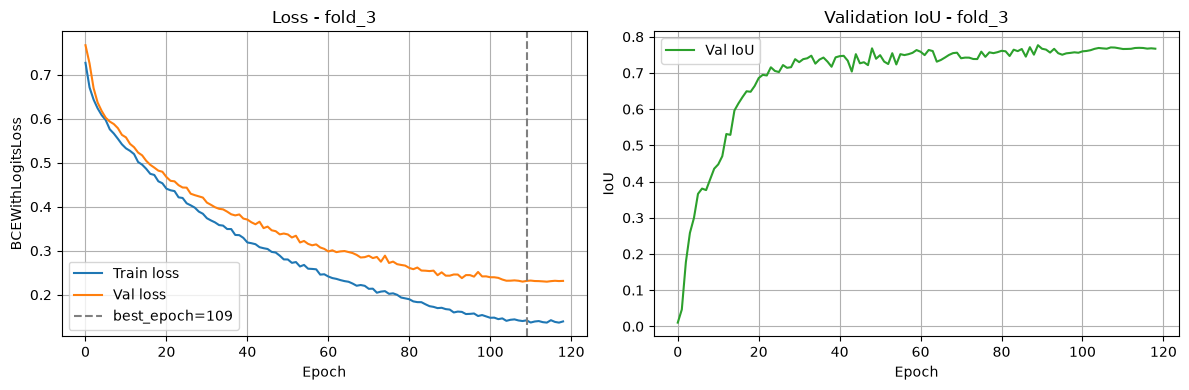

=== FOLD_3 ===
Train loss per epoch: [0.727023320538657, 0.6712158152035305, 0.643534745488848, 0.6236082911491394, 0.6081215739250183, 0.5968308363642011, 0.5759919626372201, 0.5663890327726092, 0.5545087371553693, 0.5418832557541984, 0.5327100583485195, 0.5270703860691616, 0.5196635637964521, 0.5016469955444336, 0.49559566378593445, 0.4862152763775417, 0.47483086585998535, 0.47224076305116924, 0.45783537200519014, 0.4533240241663797, 0.4410391237054552, 0.43739849754742216, 0.43556175913129536, 0.421385190316609, 0.41991487996918814, 0.4078121270452227, 0.4031737872532436, 0.39802299652780804, 0.38897779158183504, 0.384110016482217, 0.37389038290296284, 0.36888609187943594, 0.36447206139564514, 0.35837710755211966, 0.3571040758064815, 0.3493622200829642, 0.3492718040943146, 0.3358952956540244, 0.33544772011893137, 0.32930071864809307, 0.3188642348561968, 0.3171329242842538, 0.3148761349064963, 0.30810898542404175, 0.3057619460991451, 0.303978511265346, 0.2973896307604654, 0.295916123

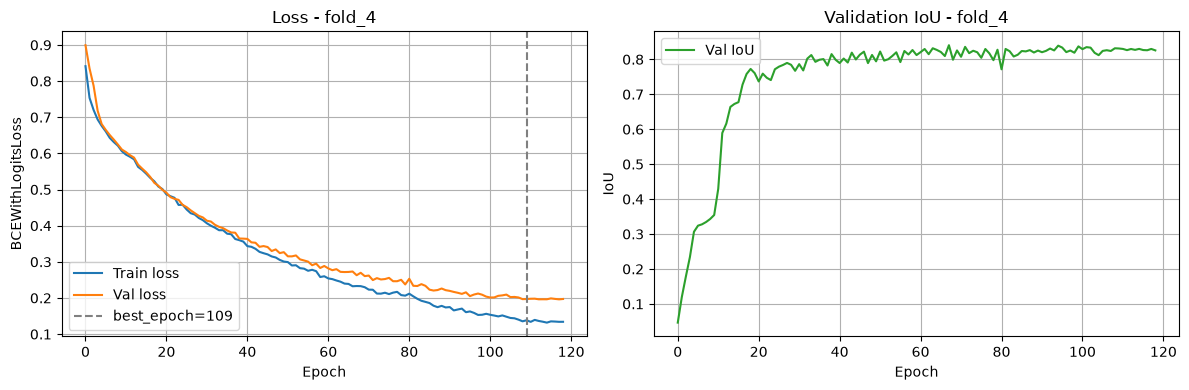

=== FOLD_4 ===
Train loss per epoch: [0.8412625204052842, 0.7535936142268934, 0.7202101632168418, 0.693875837744328, 0.6760205281408209, 0.6607926414723981, 0.6428422091300028, 0.6312900154214156, 0.6213221591815614, 0.6059779953538326, 0.5966473138123228, 0.5906340647162053, 0.5835968506963629, 0.5626218224826612, 0.5543067988596464, 0.5438509374334101, 0.5322781403859457, 0.5228911690544664, 0.5083106620269909, 0.5014563715248778, 0.48648145324305486, 0.48156423108619556, 0.4771746501587985, 0.4574198382988311, 0.45789179258179247, 0.44473070533652054, 0.4345358761779049, 0.43082996836879794, 0.4213359732376902, 0.4153217882440801, 0.40659949915450916, 0.39979791902659234, 0.39434083459670083, 0.38748738692517865, 0.3875034007064083, 0.37788292556478265, 0.37640242618426945, 0.3631439031216136, 0.3599617758341003, 0.3559602347382328, 0.3433957214941058, 0.34158246454439667, 0.33608455459276837, 0.3275165165725507, 0.3238646288712819, 0.3206047196137278, 0.31496201220311615, 0.3120268

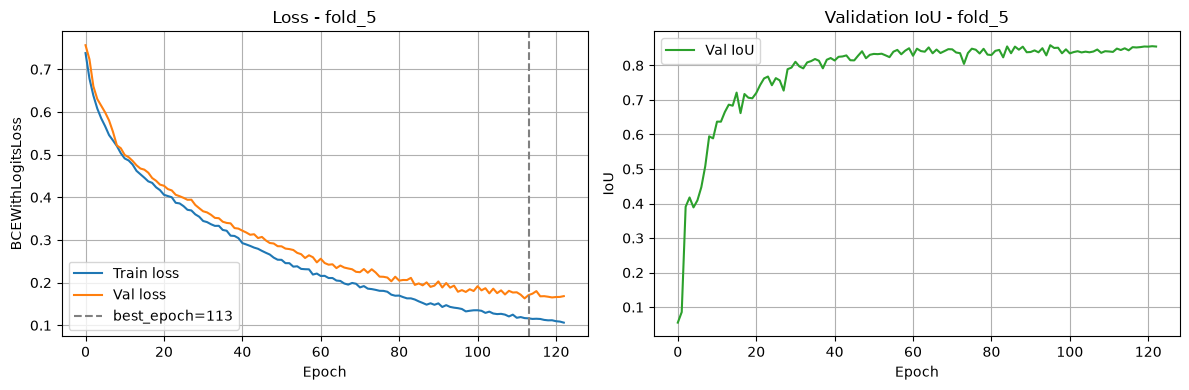

=== FOLD_5 ===
Train loss per epoch: [0.7379014964761406, 0.678282145796151, 0.6384050126733452, 0.6078875907536211, 0.585028940233691, 0.566557814335001, 0.5457747722494191, 0.5331902298434027, 0.5199948076544136, 0.5032470555141054, 0.49093035993904904, 0.486225099399172, 0.47675626031283674, 0.4619477750926182, 0.4539355193746501, 0.44591639165220587, 0.43731397184832344, 0.4337486532227746, 0.42334604777138807, 0.416664392783724, 0.40584873125470916, 0.4028597350778251, 0.4000427609887616, 0.3870466269295791, 0.3855861795359644, 0.3792455956853669, 0.37067586902914373, 0.3690970694196635, 0.35996313238966055, 0.35439894014391404, 0.3444321258314725, 0.34182172294320734, 0.33681107389515846, 0.3329535650795904, 0.3331182599067688, 0.3234577004251809, 0.3215575536777233, 0.31004042974833784, 0.3093723510873729, 0.30425232237782973, 0.2926315839948325, 0.2894275671449201, 0.2859908938407898, 0.2820637195274748, 0.2792691331485222, 0.27438041156735915, 0.2699359881466833, 0.26582682646

In [ ]:
import matplotlib.pyplot as plt

# Boucle sur les 5 folds de fold_histories
for i, (fold_name, history) in enumerate(fold_histories.items()):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Récupération de la meilleure époque pour le fold courant (si disponible)
    current_best_epoch = idx_best_epochs[i] if 'best_epochs' in locals() and i < len(best_epochs) else 0

    # 1. Loss plot (train vs val)
    axs[0].plot(history['train_loss'], label='Train loss')
    axs[0].plot(history['val_loss'], label='Val loss')
    if current_best_epoch > 0:
        axs[0].axvline(current_best_epoch, color='gray', linestyle='--', label=f'best_epoch={current_best_epoch}')
    axs[0].set_title(f'Loss - {fold_name}')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('BCEWithLogitsLoss')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Val IoU plot
    iou_key = 'val_iou_all' if 'val_iou_all' in history else 'val_iou'
    axs[1].plot(history[iou_key], label='Val IoU', color='tab:green')
    axs[1].set_title(f'Validation IoU - {fold_name}')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('IoU')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Afichage des logs pour le fold courant
    print(f"=== {fold_name.upper()} ===")
    print('Train loss per epoch:', history['train_loss'])
    print('Val loss per epoch:  ', history['val_loss'])
    print('Val IoU per epoch:   ', history[iou_key])
    print('=' * 50 + '\n')

### Sauvegarde des résultats

In [ ]:
file_path = 'results_unet_resnet34.pkl'

In [ ]:
# Sauvegarde de l'historique complet de tous les folds
with open(file_path, 'wb') as f:
    pickle.dump(fold_results, f)